# Exploratory Data Analysis

## Outline

- Random Variable: A phenomenon whose outcome is not yet known
- Statistics, Machine Learning: Guessing future values of a phenomenon, based on past observations
- Exploratory Data Analysis: Discovering basic features of variables

1. Analyze categorical/numeric variables: Mean/standard deviation, median/IQR, 
2. Analyze pairs of categorical/numeric variables

# 1. Single Variables

## Recall: Getting to Know a Variable
- Current data type, `df[var].dtype`
- Number of missings, `df[var].isna().sum()`
- Unique values it takes, `df[var].unique()`
- Counts associated with unique values, `df[var].value_counts()`
- Histogram of the value counts, `df[var].hist( bins = 35 )`

> From this, you should be able to decide whether the variable is clean enough to proceed; otherwise, go back and clean it again

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px

In [21]:
df = pd.read_csv('/Users/xpz5km/Documents/GitHub/UU/data/airbnb_HW.csv')
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [22]:
df.isna().sum()

Host Id                          0
Host Since                       3
Name                             0
Neighbourhood                    0
Property Type                    3
Review Scores Rating (bin)    8323
Room Type                        0
Zipcode                        134
Beds                            85
Number of Records                0
Number Of Reviews                0
Price                            0
Review Scores Rating          8323
dtype: int64

In [23]:
df.dtypes

Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object

In [14]:
df["review_missing"] = df["Review Scores Rating"].isna()
df["Review Scores Rating"]= df["Review Scores Rating"].fillna(df["Review Scores Rating"].mean(), inplace=True)
df.head()

/var/folders/43/f8z3kwjs27j1ztlt_wxk3q140000gp/T/ipykernel_31843/3919324228.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Review Scores Rating"]= df["Review Scores Rating"].fillna(df["Review Scores Rating"].mean(), inplace=True)
/var/folders/43/f8z3kwjs27j1ztlt_wxk3q140000gp/T/ipykernel_31843/3919324228.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,review_missing
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,None,True
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,None,True
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,None,True
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,None,True
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,None,True


In [27]:
df['Price'] = pd.to_numeric(df['Price'].str.replace(",",""), errors='coerce')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(4), object

## Statistics
- A **statistic** is a function that maps data into a number
    - Proportion: What proportion of observations take a particular label?
    - Mean: What is the average of the recorded values of the variable?

## Analyzing a Categorical
- Analyzing a categorical variable $C$ is about computing how often it takes each possible label $\ell$: How are the data spread out across labels?

- A **sample proportion** is the fraction of observations taking the value $\ell$

- Proportions of labels, among non-missing values: 
    - `df[var].value_counts(normalize=True)`
- Proportions of labels, including missing values as an additional category: 
    - `df[var].value_counts(normalize=True, dropna=False)`

- Bar/count plot for visualization: 
    - `sns.countplot(x=df[var],stat='proportion')`
    - `sns.countplot(data=df, x=var, stat='proportion')`

In [31]:
df['Property Type']

0        Apartment
1        Apartment
2        Apartment
3        Apartment
4        Apartment
           ...    
30473    Apartment
30474    Apartment
30475        Other
30476    Apartment
30477        House
Name: Property Type, Length: 30478, dtype: object

<Axes: >

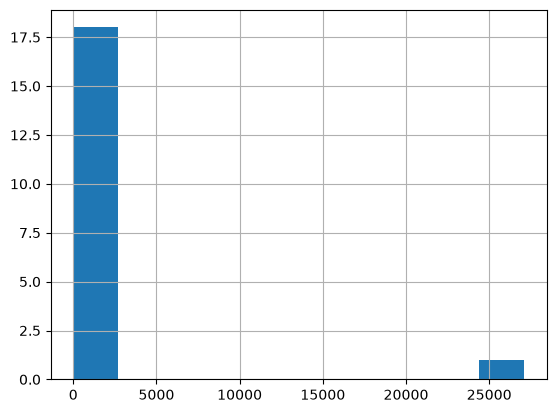

In [ ]:
df['Property Type'].value_counts()

## Analyzing a Numeric

- Analyzing a numeric variable $x$ is about computing how of: How are the data spread out across numeric values?
- To visualize the variable, `sns.histplot( df[var], bins=50)`
- For basic numeric summary, `df[var].describe()`


## Mean and Variance

- How disperse is your variable, $X = (x_1, ... , x_n)$?
- The **sample mean** is a standard measure of central tendency, the arithmetic average of the data:
$$
M(X) = \dfrac{x_1 + x_2 + ... + x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i
$$
- The **sample variance** is the arithmetic average of sum of squares of the observations from the mean,
$$
V(X) = \dfrac{1}{n} \sum_{i=1}^n (x_i - M(X))^2
$$
- The **sample standard deviation** is the square root of sample variance: $\text{sd}(x) = \sqrt{V(X)}$

## Median

- The mean and variance are particular sensitive to **outliers**: Values that are atypically high or low, and exert a lot of leverage on $M(X)$ and $V(X)$
- **Robust statistics** is the study of estimators that are less sensitive to outlier
- The **sample median** is a robust measure of central tendency, and corresponds to the value of $X$ for which half the data are above it, and half the data are below it:

$$\mathrm{med}(x) = \begin{cases}
x_{\left(\frac{n+1}{2}\right)} & n \text{ odd} \\[4pt]
\tfrac{1}{2}\left(x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}\right) & n \text{ even}
\end{cases}$$

``` python
def median(X):
    values = sorted(X) # Sort the observations
    n = len(values) # Number of observations
    middle_index = n // 2 # Determine the middle index

    if middle_index != n/2: # If the middle index is odd,
        median = values[middle_index] # that value is the median
    else: # If the middle index is even,
        median = (values[middle_index-1]+values[middle_index])/2 # average values
    return median
```

## Quantiles

- The median targets "this is the value for which half of the sample is below, and half of the sample is above"
- What if said, "I want to find the value for which a proportion $f$ of the sample is below, and $(1-f)% of the sample is above"
- This is called the **$f$-th quantile**:
  
$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}, \qquad \hat q_f = x_{(\lceil n f \rceil)}$$
``` python
from math import ceil

def quantile(X,frac):
    values = sorted(X) # Sort the observations
    n = len(values) # Number of observations
    index = max( ceil( n * frac ) - 1, 0 ) # Find frac-th index
    q = values[index] # Determine quantile value
    return q
```

- Of course, `np.quantile(X,f)` will do this for you

## Interquartile Range

- The robust analog of the variance is the **interquartile range** or IQR
- The $IQR$ is the difference between the .75 quantile and the .25 quantile:
``` python
IQR  = np.quantile(X,.75)-np.quantile(X,.25)
```
- This tells us a range that captures 50% of the total data



- The median, IQR and outliers are visualized in a **boxplot**

In [ ]:
from math import ceil
#70th percentile

def quantile(X, frac):
    values = sorted(X)
    n = len(values)
    index = max(ceil(n*frac)-1,0) #find frac-th index

    return values[index]

In [32]:
np.quantile(df['Price'], 0.7)

np.float64(175.0)

## Two Useful Transformations
- Almost every dataset I have ever opened has a few data with **long tails**: The mean is much larger or smaller than the median, because the data have a very small number of very large values
- To visualize and numerically stabilize these kinds of variables, we often take the **natural logarithm**, `df['var_ln'] = np.log(df[var])`
    - The natural log has two problems: At zero it goes to $-\infty$ and it is not defined for negative numbers
- The better choice is called the **inverse hyperbolic sine** or **arcinsh**, `df['var_ihs'] = np.arcsinh(df[var])`:
$$
i(x) = \ln \left( x + \sqrt{x^2+1} \right) 
$$
- This is defined for positive and negative values and takes the value zero at zero


# 2. Pairs of Variables

## Pairs of Categoricals

- To break out counts by two categoricals at the same time, we use a **contingency table** or **cross-tabulation**: `pd.crosstab(df[var1], df[var2])`
- This provides the joint counts for two categorical variables, allowing us to see how they vary together or not

In [33]:
pd.crosstab(df["Beds"],df["Property Type"])

Property Type,Apartment,Bed & Breakfast,Boat,Bungalow,Cabin,Camper/RV,Castle,Chalet,Condominium,Dorm,House,Hut,Lighthouse,Loft,Other,Tent,Townhouse,Treehouse,Villa
Beds,,,,,,,,,,,,,,,,,,,
0.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1.0,18415,126,2,2,1,3,1,1,53,18,1149,1,0,460,36,4,66,1,3
2.0,5906,38,5,1,0,0,0,0,25,7,423,1,1,159,8,0,32,1,2
3.0,1753,4,0,1,1,1,0,0,8,4,208,0,0,71,2,0,15,2,1
4.0,596,7,1,0,0,2,0,0,3,0,122,0,0,39,0,0,12,0,1
5.0,186,1,0,0,0,0,0,0,2,0,77,0,0,14,0,0,4,0,0
6.0,105,2,0,0,0,0,0,0,2,1,53,0,0,8,1,0,4,0,1
7.0,33,0,0,0,0,1,0,0,1,0,9,0,0,0,0,0,1,0,0
8.0,10,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0,0


## Pairs of Numerics

- How do we visualize the relationship between two variables?
- The numeric version of a contingency table is a scatterplot: `sns.scatterplot( x = df[var1], y=df[var2], alpha = .15 )`
- We often want to summarize that picture with a number, and typically use
$$
\text{cov}(X,Y) = \frac{\sum_{i=1}^n (x_i - M(X))(y_i - M(Y))}{n}
$$

- This can easily be computed: `df[[var1, var2]].cov()`

## Numeric by Categorical

- To **conditional** analysis of a numeric variable `num` on a categorical variable `cat`, we perform an analysis on subgroups of the data determined by their labelling
- To visualize a numeric conditional on a categorical, you can use `hue`: `sns.kdeplot( x = df[num], hue = df[cat], fill=True)`
- A general description by groups: `df[[cat,num]].groupby(cat).describe()`
    - Specific statistics: `df[[cat,num]].groupby(cat).count()` or `.mean()`, `.sum()`, `.count()`, etc.
    - For a custom function, `fcn()`: `df[[cat,num]].groupby(cat).agg(fcn)`
    - If you are analyzing the top or bottom of a set of observations, it often makes sense to use `.sort()` at the end

In [39]:
df.groupby("Property Type")["Price"].mean().sort_values(ascending=False)

Property Type
Other              394.659574
Villa              328.000000
Condominium        256.585106
Loft               221.960159
Townhouse          203.933824
Cabin              165.000000
Apartment          162.045642
House              156.722967
Boat               153.625000
Bungalow           150.750000
Castle             150.000000
Treehouse          149.500000
Tent               126.250000
Bed & Breakfast    106.572222
Camper/RV          103.571429
Chalet              99.000000
Dorm                76.354839
Hut                 75.000000
Lighthouse          39.000000
Name: Price, dtype: float64